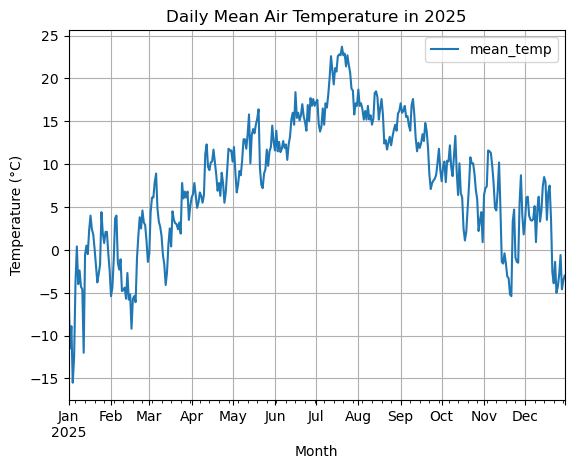

                         Mean  Median   Min   Max
Summary Statistics 2025   7.9     8.4 -15.5  23.7


In [64]:
###OPPGAVE 1####

#Importerer nødvendige biblioteker
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import yaml

client_id = '31780108-78b9-4e26-a9f2-0b0f2d7e991c'  # Sett inn din egen client_id her

#Henterer daglige middeltemperaturer, nedbør og maksimumstemperaturer for 2025 fra Frost API
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
 'sources': 'SN17850',
 'elements': 'mean(air_temperature P1D), sum(precipitation_amount P1D), max(air_temperature P1D)',
 'referencetime': '2025-01-01/2025-12-31',
 'timeoffsets': 'default'
}

#Sender GET-forespørsel til Frost API med autentisering
r = requests.get(endpoint, params=parameters, auth=(client_id, ''))

json_data_temperature = r.json()

#Henter ut observasjoner fra JSON-dataene
data_list = []
for item in json_data_temperature['data']:
    data_list.append({
        'time': item['referenceTime'],
        'mean_temp': item['observations'][0]['value'],
        'precipitation': item['observations'][1]['value'],
        'max_temp': item['observations'][2]['value']
    }) 

#Oppretter en DataFrame fra dataene og konverterer tid til datetime-format
df_t = pd.DataFrame(data_list)
df_t['time'] = pd.to_datetime(df_t['time'])

#Plotter daglige middeltemperaturer for 2025
df_t.plot(x='time', y='mean_temp', kind='line')
plt.title('Daily Mean Air Temperature in 2025')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

#Oppsummerer statistikk for daglige middeltemperaturer i 2025
summary = {
    'Mean': df_t['mean_temp'].mean(),
    'Median': df_t['mean_temp'].median(),
    'Min': df_t['mean_temp'].min(),
    'Max': df_t['mean_temp'].max()
}

summary_df_t = pd.DataFrame([summary])
summary_df_t.index = ['Summary Statistics 2025']
summary_df_t = summary_df_t.round(1)

print(summary_df_t)


Starten av koden er hentet fra oppgaven og https://frost.met.no/python_example.html Vi har også lagt til timeoffsets default etter samtale med chat og etter nettsiden til frost. Dette er fordi det er hentet data fra 00.00 og 06.00. Vi ønsket å måle fra 00-00. 



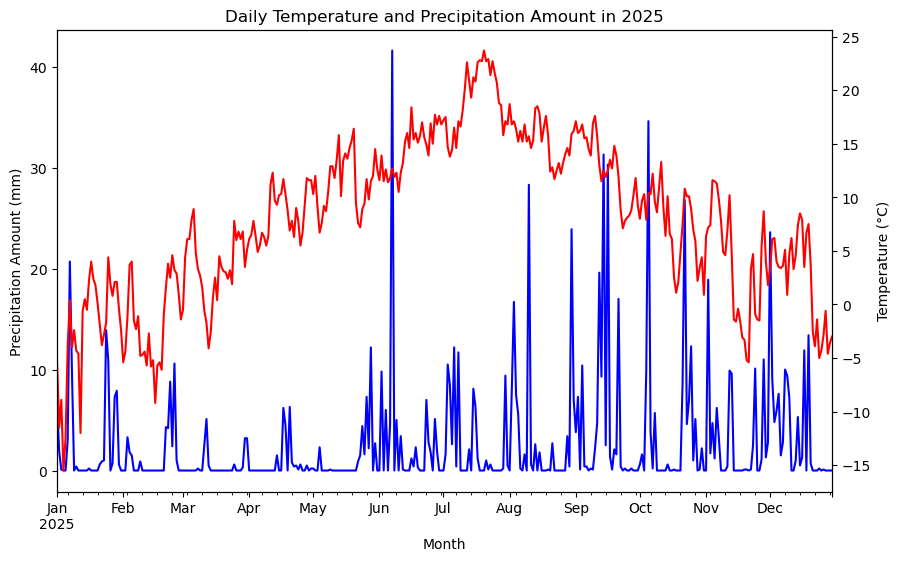

In [65]:
###Oppgave 2#####

json_data_precipitation = r.json()

#Henter ut observasjoner fra JSON-dataene
precipitation_data_list = []
for item in json_data_precipitation['data']:
    precipitation_data_list.append({
        'time': item['referenceTime'],
        'precipitation':item['observations'][1]['value']
    }) 

#Oppretter en DataFrame fra dataene
df_p = pd.DataFrame(precipitation_data_list)
df_p['time'] = pd.to_datetime(df_p['time'])

#Plotter daglige nedbørsmengder for 2025
fig, ax = plt.subplots(figsize=(10, 6))
ax1 = df_p.plot(x='time', y='precipitation', kind='line', ax=ax, color='blue', legend=False)
ax1.set_title('Daily Temperature and Precipitation Amount in 2025')
ax1.set_xlabel('Month')
ax1.set_ylabel('Precipitation Amount (mm)')

ax2 = ax1.twinx()
df_t.plot(x='time', y='mean_temp', kind='line', ax=ax2, color='red', legend=False)
ax2.set_ylabel('Temperature (°C)')  
plt.show()


Oppgave 2
vi valgte å ha linjer for begge grafene, det er dette vi synes var mest oversiktlig. Ønsket ikke kakediagram, vurderte å ha stolpediagram for regn, men vi ville ha de like. 

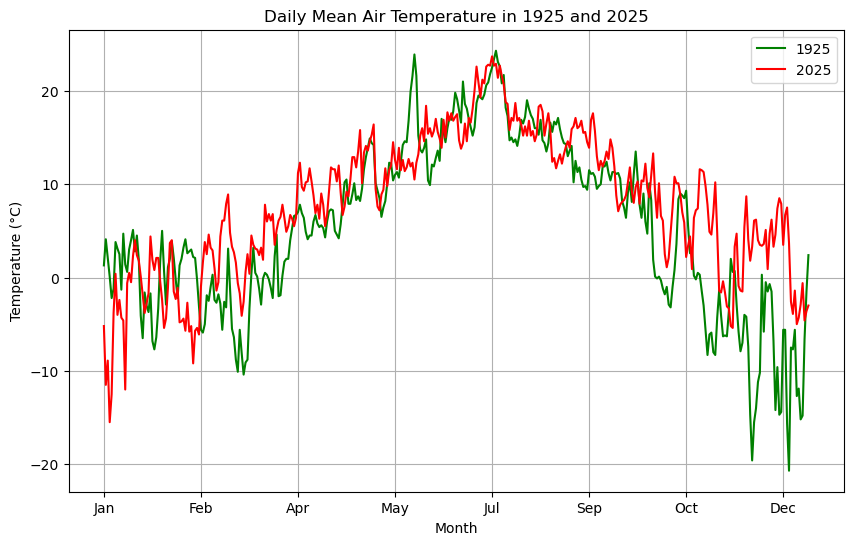

                         Mean  Median   Min   Max
Summary Statistics 2025   7.9     8.4 -15.5  23.7
Summary Statistics 1925   5.3     5.3 -20.7  24.3


In [66]:
####OPPGAVE 3#####
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
 'sources': 'SN17850',
 'elements': 'mean(air_temperature P1D)',
 'referencetime': '1925-01-01/1925-12-31',
 'timeoffsets': 'default'
}

#Sender GET-forespørsel til Frost API med autentisering
r = requests.get(endpoint, params=parameters, auth=(client_id, ''))

json_data_temperature1925 = r.json()

#Henter ut observasjoner fra JSON-dataene
data_list_1925 = []
for item in json_data_temperature1925['data']:
    data_list_1925.append({
        'time': item['referenceTime'],
        'value':item['observations'][0]['value']
    }) 

#Oppretter en DataFrame fra dataene og konverterer tid til datetime-format
df_t1925 = pd.DataFrame(data_list_1925)
df_t1925['time'] = pd.to_datetime(df_t1925['time'])
df_t1925['date'] = df_t1925['time'].dt.strftime('%b')
df_t['date'] = df_t['time'].dt.strftime('%b')

#Plotter daglige middeltemperaturer for 1925 og 2025
fig, ax = plt.subplots(figsize=(10, 6))
df_t1925.plot(x='date', y='value', kind='line', ax=ax, color='green', label='1925')
df_t.plot(x='date', y='mean_temp', kind='line', ax=ax, color='red', label='2025')
plt.title('Daily Mean Air Temperature in 1925 and 2025')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.grid(True,)
plt.show()

#Oppsummerer statistikk for daglige middeltemperaturer i 1925
summary1925 = {
    'Mean': df_t1925['value'].mean(),
    'Median': df_t1925['value'].median(),
    'Min': df_t1925['value'].min(),
    'Max': df_t1925['value'].max()
}
#Oppsummerer statistikk for daglige middeltemperaturer i 1925 og 2025 i en DataFrame
summary_df_t_1925 = pd.DataFrame([summary1925])
summary_df_t_1925.index = ['Summary Statistics 1925']
summary_df_t_1925 = summary_df_t_1925.round(1)

summary_both = pd.concat([summary_df_t, summary_df_t_1925], axis=0)    
print(summary_both)

Vi hentet daglig middeltemperatur for 1925 fra samme stasjon og plottet den sammen med 2025. Vi brukte dato i formatet måned-dag, slik at dagene ligger over hverandre i figuren.

In [67]:
###Oppgave 4###

    #Lage en funksjon som kan telle hetebølger
def count_heatwaves(df_c, threshold=27, min_length=5):
    heatwave_count = 0
    current_length = 0

    for temp in df_c['max_temp']:
        if temp >= threshold:
            current_length += 1
        else:
            if current_length >= min_length:
                heatwave_count += 1
            current_length = 0

    #sjekker om det er en hetebølge mot slutten av året
    if current_length >= min_length:
        heatwave_count += 1
    
    return heatwave_count

#Funksjon som henter data for et gitt år og teller hetebølger
def count_heatwaves_for_year(station, year):
    parameters = {
    'sources': station,
    'elements': 'max(air_temperature P1D)',
    'referencetime': f'{year}-01-01/{year}-12-31',
    'timeoffsets': 'default'
    }
    r = requests.get(endpoint, params=parameters, auth=(client_id, ''))

    json_data_choose = r.json()

    #Henter ut observasjoner fra JSON-dataene
    data_list_choose = []
    for item in json_data_choose['data']:
        data_list_choose.append({
            'time': item['referenceTime'],
            'max_temp':item['observations'][0]['value']
        }) 
    #Oppretter en DataFrame fra dataene og konverterer tid til datetime-format
    df_c = pd.DataFrame(data_list_choose)
    df_c['time'] = pd.to_datetime(df_c['time'])
    df_c['max_temp'] = df_c['max_temp'].astype(float)

    return count_heatwaves(df_c)

#Eksempel på bruk av funksjonen for å telle hetebølger i Ås i 2025
count_heatwaves_for_year('SN17850', 2025)

#Skriver en oppsummering for hetebølger til en YAML-fil
def write_summary(station, year):
    heatwave_count = count_heatwaves_for_year(station, year)
    summary = {
        'station': station,
        'year': year,
        'heatwave_count': heatwave_count
    }
    with open(f'{station}_{year}_summary.yaml', 'w') as f:
        yaml.dump(summary, f, sort_keys=False)

write_summary('SN17850', 2025)

Vi skrev en funksjon som teller hetebølger, definert som minst 5 dager på rad med maksimumstemperatur på 27 °C. Funksjonen går gjennom dagene i rekkefølge, teller sammenhengende varme dager og registrerer en hetebølge når rekken brytes etter minst 5 dager. Den sjekker også om året slutter midt i en hetebølge. En egen funksjon henter data for valgfri stasjon og år, og resultatet lagres i en YAML-fil. For Ås i 2025 fant vi 1 hetebølge.

                       time  mean_temp  moving_avg
0 2025-01-01 00:00:00+00:00       -5.2         NaN
1 2025-01-02 00:00:00+00:00      -11.5         NaN
2 2025-01-03 00:00:00+00:00       -8.9         NaN
3 2025-01-04 00:00:00+00:00      -15.5         NaN
4 2025-01-05 00:00:00+00:00      -12.5         NaN
5 2025-01-06 00:00:00+00:00       -3.8         NaN
6 2025-01-07 00:00:00+00:00        0.4   -8.142857
7 2025-01-08 00:00:00+00:00       -4.0   -7.971429
8 2025-01-09 00:00:00+00:00       -2.4   -6.671429
9 2025-01-10 00:00:00+00:00       -4.3   -6.014286


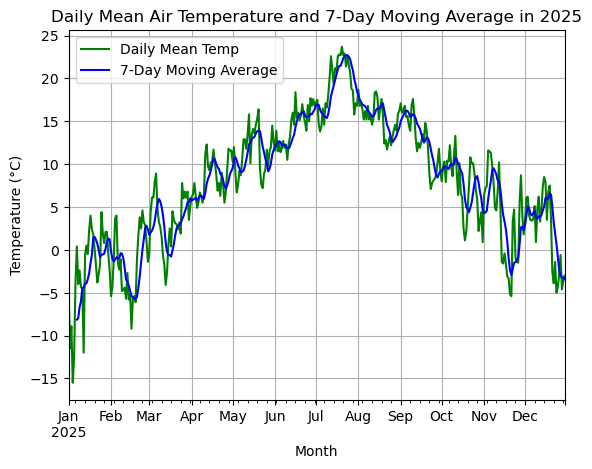

In [68]:
###OPPGAVE 5 ####
#lage 7 dagers glidene gjennomsnitt med pandas rolling funksjon
def moving_average(df, window=7):
    df['moving_avg'] = df['mean_temp'].rolling(window=window).mean()
    return df
df_t = moving_average(df_t)
print(df_t[['time', 'mean_temp', 'moving_avg']].head(10))

#Plotter daglige middeltemperaturer for 2025 og glidende gjennomsnitt
df_t.plot(x='time', y=['mean_temp', 'moving_avg'], kind='line', color=['green', 'blue'], label=['Daily Mean Temp', '7-Day Moving Average'])
plt.title('Daily Mean Air Temperature and 7-Day Moving Average in 2025')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

Vi brukte pandas sin rolling() funksjon til å regne ut et glidende gjennomsnitt over 7 dager. Hver verdi er snittet av den aktuelle dagen og de 6 foregående. Det jevner ut de store svingningene fra dag til dag, slik at det blir lettere å se hvordan temperaturen endrer seg gjennom året. De første 6 dagene får ingen verdi (NaN), fordi det ikke finnes 7 dager å regne snitt av ennå.